# 04. Stochastic Projections & Capital Risk Metrics (SST/FINMA)
### Objective
This notebook quantifies Longevity Risk by combining the LSTM champion model with Monte Carlo Dropout (MCD). We translate neural uncertainty into actionable capital metrics, specifically aligned with the Swiss Solvency Test (SST) framework.

### Actuarial Focus: Regulatory Capital
Beyond point estimates, we provide a full probability distribution of future mortality. By calculating the **Expected Shortfall (ES)**, we calibrate the Longevity SCR shock required by **FINMA**, while benchmarking our findings against traditional stochastic models.

## 4.1. Setup, Logging Silence, and Model Definition

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler

# --- 1. Silence Warnings and System Logs ---
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- 2. Load Parameters and Champion Model Details ---
if not os.path.exists('../data/interim_params.pkl') or not os.path.exists('../data/champion_params.pkl'):
    raise FileNotFoundError("Run Notebook 01 and 02 first.")

with open('../data/interim_params.pkl', 'rb') as f:
    base_data = pickle.load(f)
with open('../data/champion_params.pkl', 'rb') as f:
    champ_data = pickle.load(f)

kt = base_data['kt']
bx = base_data['bx']
alpha_x = base_data['alpha_x']
scaler_lstm = champ_data['scaler_lstm']
window_size = champ_data['window_size']

# --- 3. Define the MCD-LSTM Architecture ---
def build_mcd_lstm(input_shape):
    """
    LSTM model with Dropout active during inference for Monte Carlo sampling.
    """
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, activation='relu', return_sequences=False),
        Dropout(0.2), 
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Prepare sequences for full training
kt_scaled = scaler_lstm.transform(kt.reshape(-1, 1))
X_all, y_all = [], []
for i in range(len(kt_scaled) - window_size):
    X_all.append(kt_scaled[i:(i + window_size), 0])
    y_all.append(kt_scaled[i + window_size, 0])
X_all, y_all = np.array(X_all).reshape(-1, window_size, 1), np.array(y_all)

# Initialize and train the Probabilistic Model
model_mcd = build_mcd_lstm((window_size, 1))
print("Training MCD-LSTM for stochastic projections...")
model_mcd.fit(X_all, y_all, epochs=200, batch_size=32, verbose=0)

print("MCD-LSTM trained and ready.")

Training MCD-LSTM for stochastic projections...
MCD-LSTM trained and ready.


## 4.2. Stochastic Forecasting (2025-2050)

In [25]:
n_future = 2050 - 2024
n_sims = 100 
all_sims = []

print(f"Starting Stochastic Projections (2025-2050)...")
print(f"Generating {n_sims} trajectories via MC Dropout")

for s in range(n_sims):
    curr_batch = kt_scaled[-window_size:].reshape((1, window_size, 1))
    sim_path = []
    for _ in range(n_future):
        # training=True enables Dropout during prediction
        next_v = model_mcd(curr_batch, training=True).numpy()[0, 0]
        sim_path.append(next_v)
        # Update sliding window with the new prediction
        next_v_reshaped = np.array(next_v).reshape(1, 1, 1)
        curr_batch = np.append(curr_batch[:, 1:, :], next_v_reshaped, axis=1)
    
    # Invert scaling back to mortality index (kt) space
    all_sims.append(scaler_lstm.inverse_transform(np.array(sim_path).reshape(-1, 1)).flatten())
    
    if (s + 1) % 20 == 0:
        print(f" > Progress: {s + 1}/{n_sims} simulations completed")

all_sims = np.array(all_sims)
future_years = np.arange(2025, 2051)
print("\nStochastic projections complete.")

Starting Stochastic Projections (2025-2050)...
Generating 100 trajectories via MC Dropout
 > Progress: 20/100 simulations completed
 > Progress: 40/100 simulations completed
 > Progress: 60/100 simulations completed
 > Progress: 80/100 simulations completed
 > Progress: 100/100 simulations completed

Stochastic projections complete.


## 4.3. Neural Fan Chart

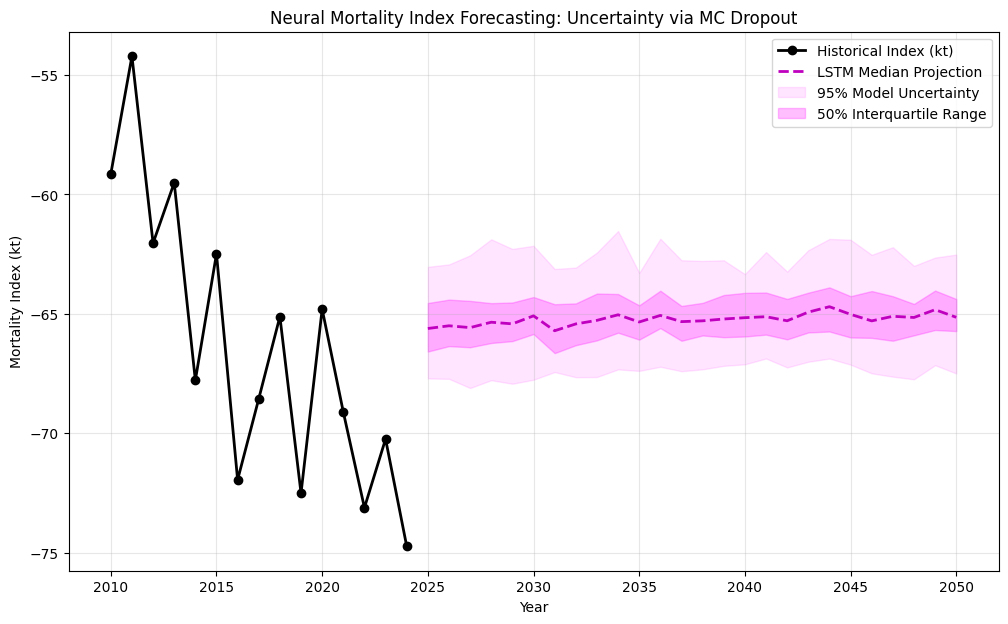

In [26]:
# Calculate summary statistics for the projections
median_proj = np.percentile(all_sims, 50, axis=0)
lower_95 = np.percentile(all_sims, 2.5, axis=0)
upper_95 = np.percentile(all_sims, 97.5, axis=0)
lower_50 = np.percentile(all_sims, 25, axis=0)
upper_50 = np.percentile(all_sims, 75, axis=0)

plt.figure(figsize=(12, 7))

# Historical data (context)
plt.plot(np.arange(2010, 2025), kt[-15:], 'ko-', label='Historical Index (kt)', linewidth=2)

# Median neural projection
plt.plot(future_years, median_proj, 'm--', label='LSTM Median Projection', linewidth=2)

# Uncertainty bands
plt.fill_between(future_years, lower_95, upper_95, color='magenta', alpha=0.1, label='95% Model Uncertainty')
plt.fill_between(future_years, lower_50, upper_50, color='magenta', alpha=0.25, label='50% Interquartile Range')

plt.title('Neural Mortality Index Forecasting: Uncertainty via MC Dropout')
plt.xlabel('Year'); plt.ylabel('Mortality Index (kt)'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('../reports/figures/07_lstm_uncertainty_fan.png', dpi=300)
plt.show()

## 4.4. Model Risk Benchmark - LC vs LSTM

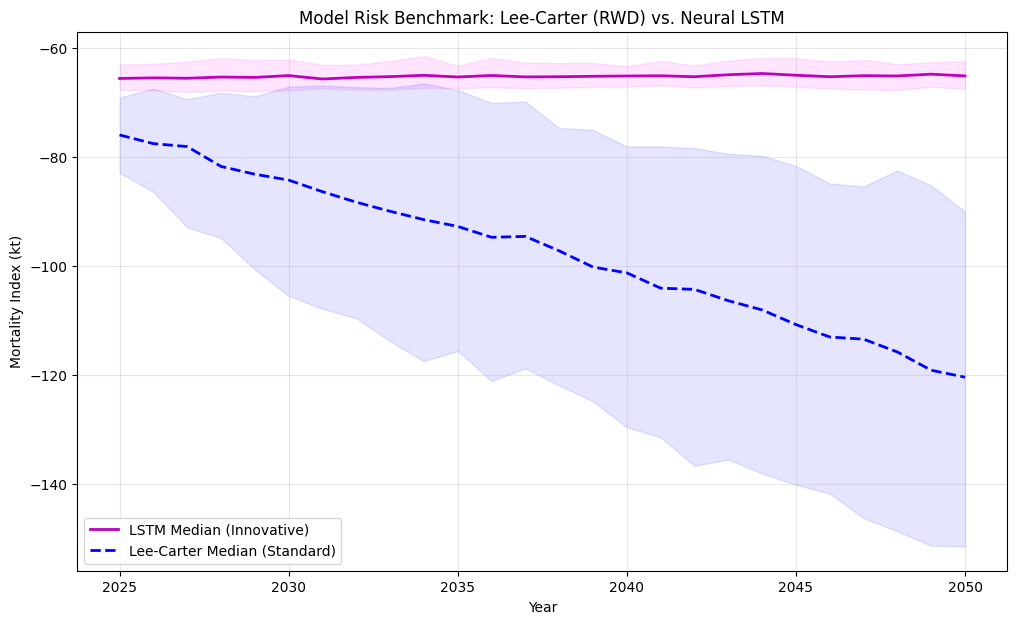

Difference in 2050 Medians: 55.2764


In [27]:
# 1. Lee-Carter Random Walk with Drift (Industry Benchmark)
d = (kt[-1] - kt[0]) / (len(kt) - 1)
sigma_kt = np.std(np.diff(kt))
lc_sims = np.zeros((n_sims, len(future_years)))

for s in range(n_sims):
    curr_k = kt[-1]
    for t in range(len(future_years)):
        curr_k += d + np.random.normal(0, sigma_kt)
        lc_sims[s, t] = curr_k

lc_median = np.percentile(lc_sims, 50, axis=0)
lc_lower_95 = np.percentile(lc_sims, 2.5, axis=0)
lc_upper_95 = np.percentile(lc_sims, 97.5, axis=0)

# 2. Comparison Visualization
plt.figure(figsize=(12, 7))

# LSTM (The Challenger)
plt.plot(future_years, median_proj, 'm-', label='LSTM Median (Innovative)', linewidth=2)
plt.fill_between(future_years, lower_95, upper_95, color='magenta', alpha=0.1)

# Lee-Carter (The Benchmark)
plt.plot(future_years, lc_median, 'b--', label='Lee-Carter Median (Standard)', linewidth=2)
plt.fill_between(future_years, lc_lower_95, lc_upper_95, color='blue', alpha=0.1)

plt.title('Model Risk Benchmark: Lee-Carter (RWD) vs. Neural LSTM')
plt.xlabel('Year'); plt.ylabel('Mortality Index (kt)'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('../reports/figures/08_lstm_vs_lc_benchmark.png', dpi=300)
plt.show()

print(f"Difference in 2050 Medians: {median_proj[-1] - lc_median[-1]:.4f}")

## 4.5. SST Risk Metrics & Capital Distribution

--- Longevity Risk Analysis (Year 2050) ---
Best Estimate (Median kt): -65.1415

Confidence Level: 95.0%
  > Value at Risk (VaR): -66.9869
  > Expected Shortfall (ES): -67.5202
  > Longevity SCR Shock (Δkt): 1.8454
----------------------------------------
Confidence Level: 99.0%
  > Value at Risk (VaR): -67.7260
  > Expected Shortfall (ES): -67.8554
  > Longevity SCR Shock (Δkt): 2.5845
----------------------------------------
Confidence Level: 99.5%
  > Value at Risk (VaR): -67.7907
  > Expected Shortfall (ES): -67.8554
  > Longevity SCR Shock (Δkt): 2.6492
----------------------------------------


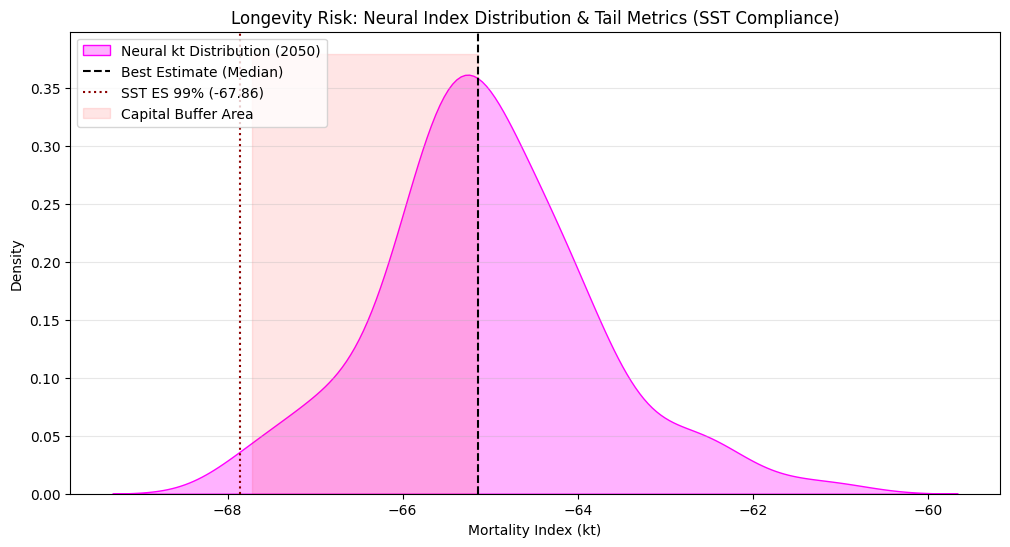

In [28]:
kt_2050 = all_sims[:, -1]
median_kt = np.percentile(kt_2050, 50)
conf_levels = [0.95, 0.99, 0.995]

print(f"--- Longevity Risk Analysis (Year 2050) ---")
print(f"Best Estimate (Median kt): {median_kt:.4f}\n")

risk_results = []
for cl in conf_levels:
    var_cl = np.percentile(kt_2050, (1 - cl) * 100)
    es_cl = kt_2050[kt_2050 <= var_cl].mean()
    shock = median_kt - var_cl
    risk_results.append({'CL': cl, 'VaR': var_cl, 'ES': es_cl, 'Shock': shock})
    
    print(f"Confidence Level: {cl*100}%")
    print(f"  > Value at Risk (VaR): {var_cl:.4f}")
    print(f"  > Expected Shortfall (ES): {es_cl:.4f}")
    print(f"  > Longevity SCR Shock (Δkt): {shock:.4f}")
    print("-" * 40)

# Final Capital Distribution Visualization
plt.figure(figsize=(12, 6))
sns.kdeplot(kt_2050, fill=True, color="magenta", alpha=0.3, label="Neural kt Distribution (2050)")

plt.axvline(median_kt, color='black', linestyle='--', label='Best Estimate (Median)')
# SST Focus (99% ES)
plt.axvline(risk_results[1]['ES'], color='darkred', linestyle=':', label=f"SST ES 99% ({risk_results[1]['ES']:.2f})")
# Area highlighting the Capital Buffer (SST/Solvency II)
plt.fill_betweenx(np.linspace(0, plt.gca().get_ylim()[1], 10), 
                 risk_results[1]['VaR'], median_kt, color='red', alpha=0.1, label='Capital Buffer Area')

plt.title('Longevity Risk: Neural Index Distribution & Tail Metrics (SST Compliance)')
plt.xlabel('Mortality Index (kt)'); plt.ylabel('Density'); plt.legend(loc='upper left'); plt.grid(axis='y', alpha=0.3)
plt.savefig('../reports/figures/09_longevity_risk_distribution.png', dpi=300)
plt.show()